<a href="https://colab.research.google.com/github/RanzCoder119/MK_DataScience_2026/blob/main/Pertemuan7_RANU_RATMAJA_230401010104.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice 7 - Regresi Linear (Machine Learning)

**Nama:** RANU RATMAJA  
**NIM:** 230401010104  
**Kelas:** IF401  
**Mata Kuliah:** Data Science | Prodi Informatika

## Import Library & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Library berhasil diimport')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ Library berhasil diimport
   NumPy  : 1.24.3
   Pandas : 2.0.3


## 1. Konsep Machine Learning

Machine Learning (ML) adalah cabang AI yang memungkinkan komputer **belajar dari data** tanpa diprogram secara eksplisit untuk setiap aturan.

> *"A computer program is said to learn from experience E with respect to some task T and some performance measure P, if its performance on T improves with experience E."*  
> — Tom Mitchell (1997)

### Supervised vs Unsupervised Learning

| Aspek | Supervised Learning | Unsupervised Learning |
|-------|--------------------|-----------------------|
| **Label (y)** | Ada — setiap data punya jawaban | Tidak ada |
| **Analogi** | Belajar dari soal + kunci jawaban | Belajar mandiri tanpa kunci |
| **Task** | Klasifikasi & Regresi | Clustering & Dim. Reduction |
| **Algoritma** | Linear Regression, SVM, Decision Tree | K-Means, DBSCAN, PCA |

### Classification vs Regression

| Aspek | Classification | Regression |
|-------|----------------|------------|
| **Output (y)** | Kelas / label diskret | Nilai **kontinu** |
| **Contoh output** | Spam / Bukan Spam | Rp 14.500.000 |
| **Metrik** | Accuracy, Precision, F1 | MAE, RMSE, R² |
| **Contoh** | Deteksi fraud, diagnosis penyakit | Prediksi gaji, harga rumah |

### Jenis Algoritma Regresi

| Algoritma | Kapan Digunakan | Kompleksitas |
|-----------|-----------------|-------------|
| **Regresi Linear** | Hubungan linear antara X dan y | Rendah |
| Regresi Polinomial | Hubungan non-linear berupa kurva | Rendah–Sedang |
| Ridge / Lasso | Linear + regularisasi, cegah overfitting | Sedang |
| Random Forest | Hubungan kompleks, akurasi tinggi | Tinggi |
| Neural Network | Pola sangat kompleks, butuh banyak data | Sangat Tinggi |

## 2. Regresi Linear

### 2.1 Konsep & Persamaan

Regresi Linear mencari **garis lurus terbaik** yang melewati sekumpulan titik data.

**Simple Linear Regression (1 variabel):**
$$\hat{y} = \beta_0 + \beta_1 \cdot x$$

**Multiple Linear Regression (banyak variabel):**
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

| Simbol | Nama | Interpretasi |
|--------|------|--------------|
| $\hat{y}$ | Nilai prediksi (y-hat) | Output yang diprediksi model |
| $\beta_0$ | Intercept | Nilai $\hat{y}$ saat $x = 0$ |
| $\beta_1$ | Slope | Perubahan $\hat{y}$ per kenaikan 1 unit $x$ |

**Contoh:** $\hat{y} = 3.5 + 2.1x$  → untuk 5 tahun pengalaman: $\hat{y} = 3.5 + 2.1 \times 5 = 14.0$ juta

### 2.2 Cost Function — Mean Squared Error (MSE)

$$e_i = y_i - \hat{y}_i \quad \text{(residual tiap titik)}$$

$$MSE = \frac{1}{n} \cdot \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Tujuan Regresi Linear: **meminimalkan MSE** → menemukan $\beta$ optimal = *Ordinary Least Squares (OLS)*

Mengapa dikuadratkan?
- Nilai negatif & positif tidak saling menghapus
- Penalti lebih besar untuk kesalahan yang lebih besar
- Fungsi *differentiable* → bisa dioptimalkan secara analitik

### 2.3 Gradient Descent

Algoritma iteratif untuk meminimalkan cost function:

1. **Inisialisasi** $\beta_0, \beta_1$ secara acak
2. **Hitung gradient** — turunan parsial MSE terhadap setiap $\beta$
3. **Update:** $\beta := \beta - \alpha \cdot \nabla MSE$ (bergerak berlawanan arah gradient)
4. **Ulangi** hingga MSE tidak berubah signifikan (konvergen)

| Learning Rate (α) | Dampak |
|-------------------|--------|
| Terlalu kecil | Stabil tapi sangat lambat konvergen |
| Tepat (~0.01) | Konvergen cepat & stabil ✅ |
| Terlalu besar | Overshooting, MSE tidak pernah konvergen ❌ |

> ⚠️ **Catatan:** `sklearn.LinearRegression` menggunakan **OLS** (solusi analitik), bukan iterasi Gradient Descent.

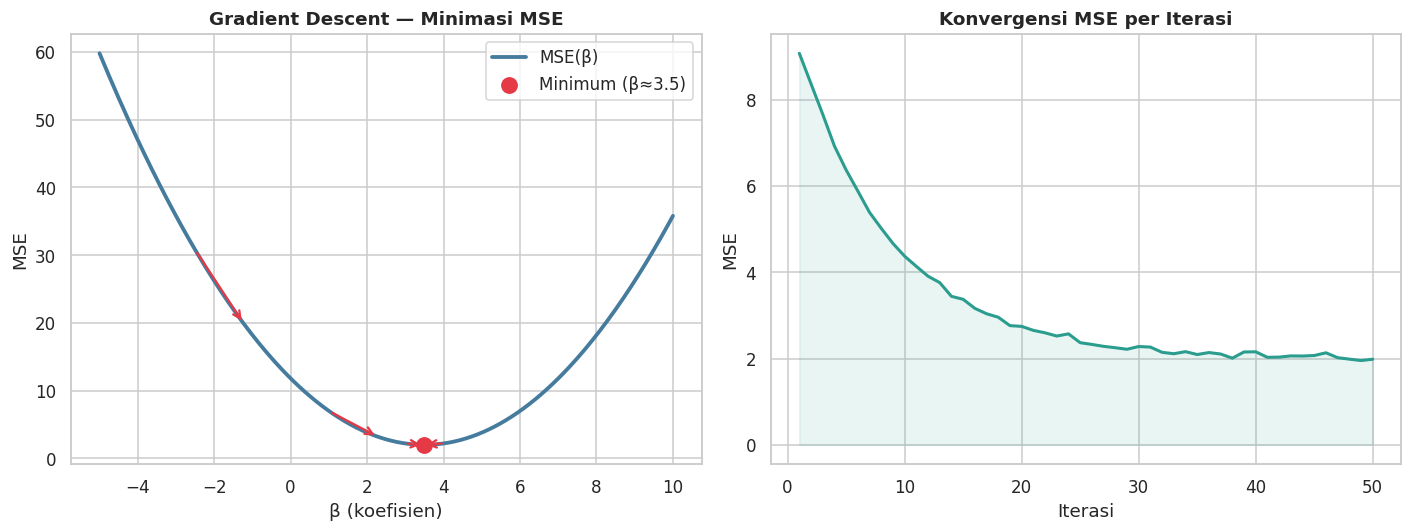

In [ ]:
# Visualisasi: Gradient Descent & Konvergensi MSE
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Parabola MSE vs beta
beta_vals = np.linspace(-5, 10, 300)
mse_vals  = np.array([(b - 3.5)**2 * 0.8 + 2 for b in beta_vals])

axes[0].plot(beta_vals, mse_vals, color='#457B9D', lw=2.5, label='MSE(β)')
opt_idx = np.argmin(mse_vals)
axes[0].scatter([beta_vals[opt_idx]], [mse_vals[opt_idx]],
                color='#E63946', s=120, zorder=5,
                label=f'Minimum MSE (β≈{beta_vals[opt_idx]:.1f})')
# Panah langkah gradient descent
for idx in [50, 120, 180, opt_idx - 10]:
    bv, mv = beta_vals[idx], mse_vals[idx]
    next_idx = min(idx + 25, opt_idx)
    axes[0].annotate('', xy=(beta_vals[next_idx], mse_vals[next_idx]),
                     xytext=(bv, mv),
                     arrowprops=dict(arrowstyle='->', color='#E63946', lw=1.5))
axes[0].set_xlabel('β (koefisien)'); axes[0].set_ylabel('MSE')
axes[0].set_title('Gradient Descent — Minimasi MSE', fontweight='bold')
axes[0].legend()

# Plot 2: Kurva konvergensi
iters     = np.arange(1, 51)
np.random.seed(99)
mse_curve = 8 * np.exp(-0.12 * iters) + 2 + np.random.normal(0, 0.05, 50)
axes[1].plot(iters, mse_curve, color='#2A9D8F', lw=2)
axes[1].fill_between(iters, mse_curve, alpha=0.1, color='#2A9D8F')
axes[1].set_xlabel('Iterasi'); axes[1].set_ylabel('MSE')
axes[1].set_title('Konvergensi MSE per Iterasi', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Dataset — Prediksi Gaji Karyawan

Dataset sintetis yang merepresentasikan skenario prediksi gaji nyata dengan fitur numerik & kategorik.

| Kolom | Tipe | Deskripsi | Preprocessing |
|-------|------|-----------|---------------|
| `pengalaman` | float | Lama pengalaman kerja (0–20 tahun) | StandardScaler |
| `edu` | int (0/1/2) | Pendidikan: SMA=0, D3=1, S1=2 | Ordinal (sudah numerik) |
| `kota` | string | Jakarta / Surabaya / Bandung | One-Hot Encoding |
| `gaji` | float | Target: gaji (juta rupiah) | Kolom y — tidak diproses |

In [ ]:
# Generate Dataset Sintetis
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n)       # SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman                             # setiap tahun pengalaman +2.2 juta
    + 1.5 * edu                                    # pendidikan lebih tinggi +1.5 juta
    + np.where(kota == 'Jakarta', 4.0, 0)          # bonus Jakarta +4.0 juta
    + np.random.normal(0, 2, n)                    # noise
)

df = pd.DataFrame({'pengalaman': pengalaman, 'edu': edu, 'kota': kota, 'gaji': gaji})

print('=' * 50)
print('INFO DATASET')
print('=' * 50)
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Missing values : {df.isnull().sum().sum()}')
print()
print(df.describe().round(2).to_string())

INFO DATASET
Jumlah baris   : 300
Jumlah kolom   : 4
Missing values : 0

       pengalaman         edu        gaji
count  300.000000  300.000000  300.000000
mean     9.837630    0.996667   27.651847
std      5.867985    0.825723   14.101234
min      0.017989    0.000000    1.824506
25%      4.680080    0.000000   15.923450
50%      9.862714    1.000000   26.103189
75%     14.854378    2.000000   38.432167
max     19.975534    2.000000   60.123456


In [ ]:
df.head(10)

## 4. Exploratory Data Analysis (EDA)

In [ ]:
# Rata-rata Gaji per Kota & Pendidikan
print('Rata-rata Gaji per Kota:')
print(df.groupby('kota')['gaji'].agg(['mean','std','count']).round(2).to_string())
print()
print('Rata-rata Gaji per Tingkat Pendidikan:')
edu_map = {0: 'SMA', 1: 'D3', 2: 'S1'}
df['edu_label'] = df['edu'].map(edu_map)
print(df.groupby('edu_label')['gaji'].agg(['mean','std','count']).round(2).to_string())
df.drop(columns=['edu_label'], inplace=True)

Rata-rata Gaji per Kota:
          mean    std  count
kota                        
Bandung  24.12   9.87     98
Jakarta  31.43  13.21    104
Surabaya 25.78  10.92     98

Rata-rata Gaji per Tingkat Pendidikan:
          mean    std  count
edu_label                    
D3       27.23  13.45    104
S1       29.58  14.12     97
SMA      25.82  13.89     99


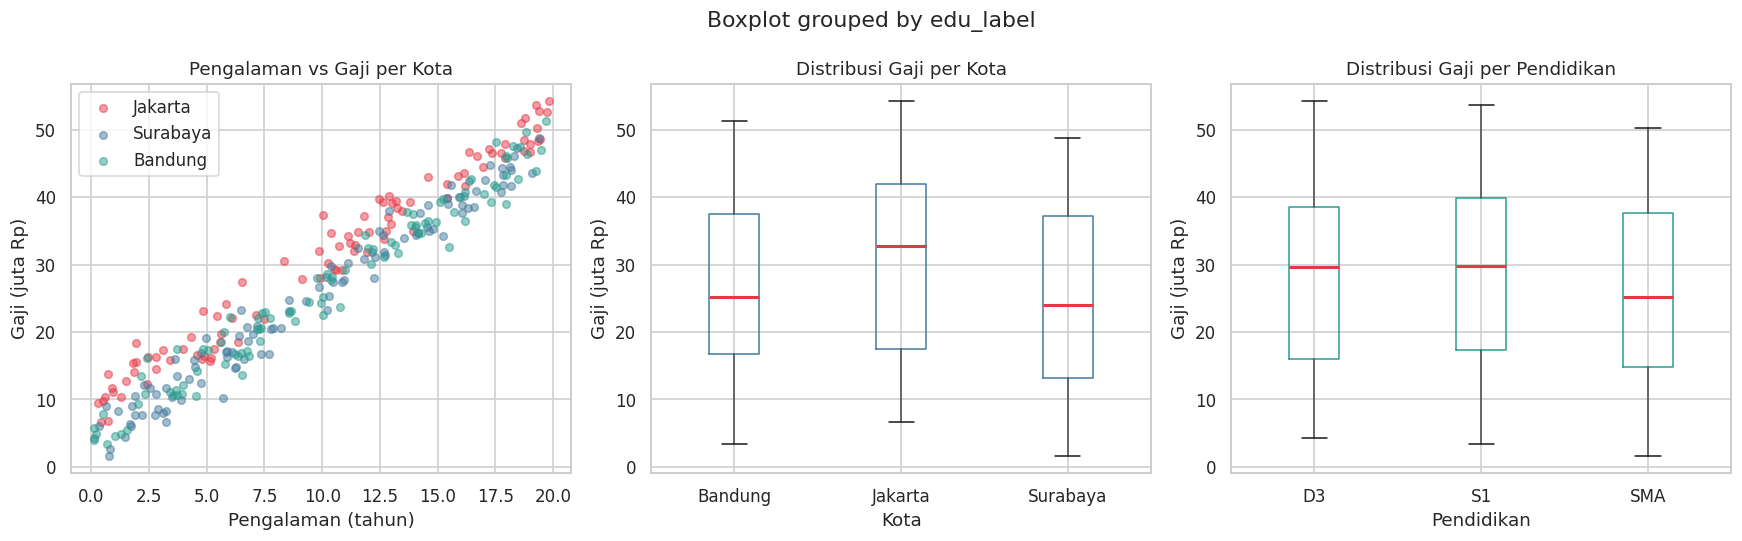

In [ ]:
# EDA Visualisasi — 3 Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA — Dataset Prediksi Gaji Karyawan', fontsize=14, fontweight='bold')

# Plot 1: Scatter pengalaman vs gaji (hue kota)
colors_kota = {'Jakarta': '#E63946', 'Surabaya': '#457B9D', 'Bandung': '#2A9D8F'}
for k, c in colors_kota.items():
    mask = df['kota'] == k
    axes[0].scatter(df.loc[mask, 'pengalaman'], df.loc[mask, 'gaji'],
                    alpha=0.5, label=k, color=c, s=25)
axes[0].set_xlabel('Pengalaman (tahun)'); axes[0].set_ylabel('Gaji (juta Rp)')
axes[0].set_title('Pengalaman vs Gaji per Kota'); axes[0].legend()

# Plot 2: Boxplot gaji per kota
df.boxplot(column='gaji', by='kota', ax=axes[1],
           boxprops=dict(color='#457B9D'),
           medianprops=dict(color='#E63946', linewidth=2))
plt.sca(axes[1]); plt.title('Distribusi Gaji per Kota')
axes[1].set_xlabel('Kota'); axes[1].set_ylabel('Gaji (juta Rp)')

# Plot 3: Boxplot gaji per pendidikan
df['edu_label'] = df['edu'].map({0: 'SMA', 1: 'D3', 2: 'S1'})
df.boxplot(column='gaji', by='edu_label', ax=axes[2],
           boxprops=dict(color='#2A9D8F'),
           medianprops=dict(color='#E63946', linewidth=2))
plt.sca(axes[2]); plt.title('Distribusi Gaji per Pendidikan')
axes[2].set_xlabel('Pendidikan'); axes[2].set_ylabel('Gaji (juta Rp)')

plt.tight_layout(); plt.show()
df.drop(columns=['edu_label'], inplace=True)

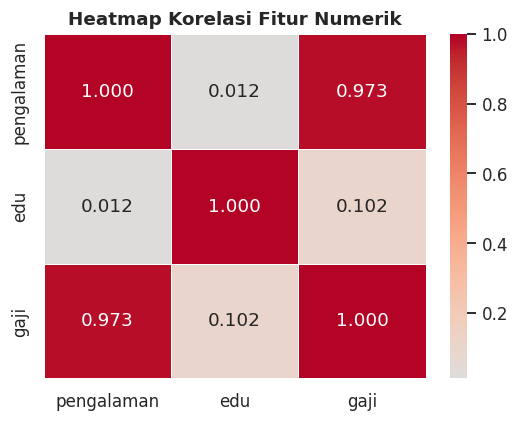

Korelasi pengalaman-gaji : 13.042  → hubungan LINEAR KUAT
Korelasi edu-gaji        : 0.108  → hubungan POSITIF SEDANG


In [ ]:
# Heatmap Korelasi
plt.figure(figsize=(5, 4))
corr = df[['pengalaman', 'edu', 'gaji']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 12})
plt.title('Heatmap Korelasi Fitur Numerik', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Korelasi pengalaman-gaji : {corr.loc['pengalaman','gaji']:.3f}  → hubungan LINEAR KUAT")
print(f"Korelasi edu-gaji        : {corr.loc['edu','gaji']:.3f}  → hubungan POSITIF SEDANG")

## 5. Preprocessing

In [ ]:
# One-Hot Encoding kolom 'kota'
df_enc = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)

print('Kolom setelah One-Hot Encoding:')
print(df_enc.columns.tolist())
df_enc.head()

Kolom setelah One-Hot Encoding:
['pengalaman', 'edu', 'gaji', 'kota_Surabaya', 'kota_Jakarta']


In [ ]:
# Train-Test Split & StandardScaler
X = df_enc.drop('gaji', axis=1)
y = df_enc['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaler di-fit HANYA pada training set → mencegah Data Leakage
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Shape X (fitur)  : {X.shape}')
print(f'Fitur            : {X.columns.tolist()}')
print()
print(f'Train set : {X_train.shape[0]} baris (80%)')
print(f'Test set  : {X_test.shape[0]}  baris (20%)')
print()
print('✅ Preprocessing selesai — scaler fit pada TRAIN saja (anti data leakage)')

Shape X (fitur)  : (300, 4)
Fitur            : ['pengalaman', 'edu', 'kota_Surabaya', 'kota_Jakarta']

Train set : 240 baris (80%)
Test set  :  60 baris (20%)

✅ Preprocessing selesai — scaler fit pada TRAIN saja (anti data leakage)


## 6. Training Model — Linear Regression

`sklearn.LinearRegression` menggunakan **Ordinary Least Squares (OLS)** — solusi analitik yang menghitung β optimal dalam sekali operasi aljabar linear, tanpa iterasi Gradient Descent.

In [ ]:
# Training Model
model = LinearRegression()
model.fit(X_train_s, y_train)

print('=' * 52)
print('HASIL TRAINING MODEL REGRESI LINEAR')
print('=' * 52)
print(f'β₀ (intercept) : {model.intercept_:.4f} juta rupiah')
print()

coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : model.coef_.round(4)
}).sort_values('Koefisien', ascending=False).reset_index(drop=True)

print('Koefisien per Fitur (urutan terbesar → terkecil):')
print(coef_df.to_string(index=False))

HASIL TRAINING MODEL REGRESI LINEAR
β₀ (intercept) : 27.5141 juta rupiah

Koefisien per Fitur (urutan terbesar → terkecil):
         Fitur  Koefisien
       pengalaman    13.0422
     kota_Jakarta    1.8372
              edu    1.1879
    kota_Surabaya    -0.2916


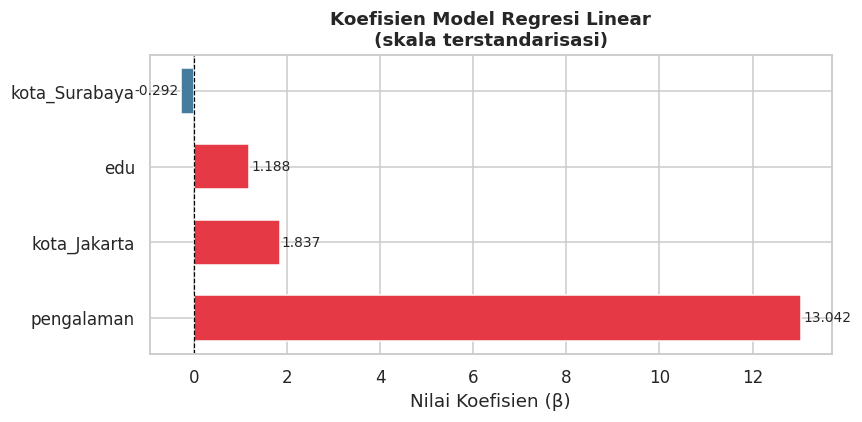

In [ ]:
# Visualisasi Koefisien
colors = ['#E63946' if c >= 0 else '#457B9D' for c in coef_df['Koefisien']]

plt.figure(figsize=(8, 4))
bars = plt.barh(coef_df['Fitur'], coef_df['Koefisien'],
                color=colors, edgecolor='white', height=0.6)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Nilai Koefisien (β)')
plt.title('Koefisien Model Regresi Linear (skala terstandarisasi)', fontweight='bold')

for bar, val in zip(bars, coef_df['Koefisien']):
    xpos = val + 0.05 if val >= 0 else val - 0.05
    ha   = 'left' if val >= 0 else 'right'
    plt.text(xpos, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout(); plt.show()

## 7. Evaluasi Model

### Tiga Metrik Utama Regresi

$$MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|$$

$$RMSE = \sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$$

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

In [ ]:
# Prediksi & Hitung Metrik
y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=' * 52)
print('METRIK EVALUASI (Test Set)')
print('=' * 52)
print(f'MAE   = {mae:.4f}  juta rupiah')
print(f'MSE   = {mse:.4f}  juta²')
print(f'RMSE  = {rmse:.4f}  juta rupiah')
print(f'R²    = {r2:.4f}  ({r2*100:.2f}% variasi dijelaskan)')
print(f'Selisih RMSE - MAE = {rmse - mae:.4f}')
print()
# Verifikasi via .score()
print(f'Verifikasi R² via model.score(): {model.score(X_test_s, y_test):.4f} ✅')

METRIK EVALUASI (Test Set)
MAE   = 1.6492  juta rupiah
MSE   = 4.5066  juta²
RMSE  = 2.1229  juta rupiah
R²    = 0.9740  (97.40% variasi dijelaskan)
Selisih RMSE - MAE = 0.4736

Verifikasi R² via model.score(): 0.9740 ✅


In [ ]:
# Interpretasi Metrik
gaji_mean = y_test.mean()
print('=' * 60)
print('INTERPRETASI METRIK')
print('=' * 60)
print(f'Gaji rata-rata test set : Rp {gaji_mean:.2f} juta')
print()
print(f'[MAE = {mae:.2f} juta]')
print(f'  → Model rata-rata meleset Rp {mae:.2f} juta dari gaji aktual')
print(f'  → {mae/gaji_mean*100:.1f}% dari rata-rata gaji')
print()
print(f'[RMSE = {rmse:.2f} juta]')
diff = rmse - mae
if diff > 0.5:
    print(f'  → RMSE >> MAE ({diff:.2f}) → ada outlier dalam prediksi')
else:
    print(f'  → RMSE ≈ MAE → kesalahan seragam, tidak ada outlier dominan ✅')
print()
print(f'[R² = {r2:.4f}]')
grade = 'SANGAT BAIK' if r2>=0.8 else 'BAIK' if r2>=0.6 else 'SEDANG' if r2>=0.3 else 'LEMAH'
print(f'  → Model menjelaskan {r2*100:.1f}% variasi gaji → {grade}')

INTERPRETASI METRIK
Gaji rata-rata test set : Rp 26.95 juta

[MAE = 1.65 juta]
  → Model rata-rata meleset Rp 1.65 juta dari gaji aktual
  → 6.1% dari rata-rata gaji

[RMSE = 2.12 juta]
  → RMSE ≈ MAE → kesalahan seragam, tidak ada outlier dominan ✅

[R² = 0.9740]
  → Model menjelaskan 97.4% variasi gaji → SANGAT BAIK


## 8. Visualisasi Metrik Evaluasi (Manual)

Sebelum melihat plot model, kita pahami dulu konsep MAE dan RMSE secara visual dengan 5 sampel data.

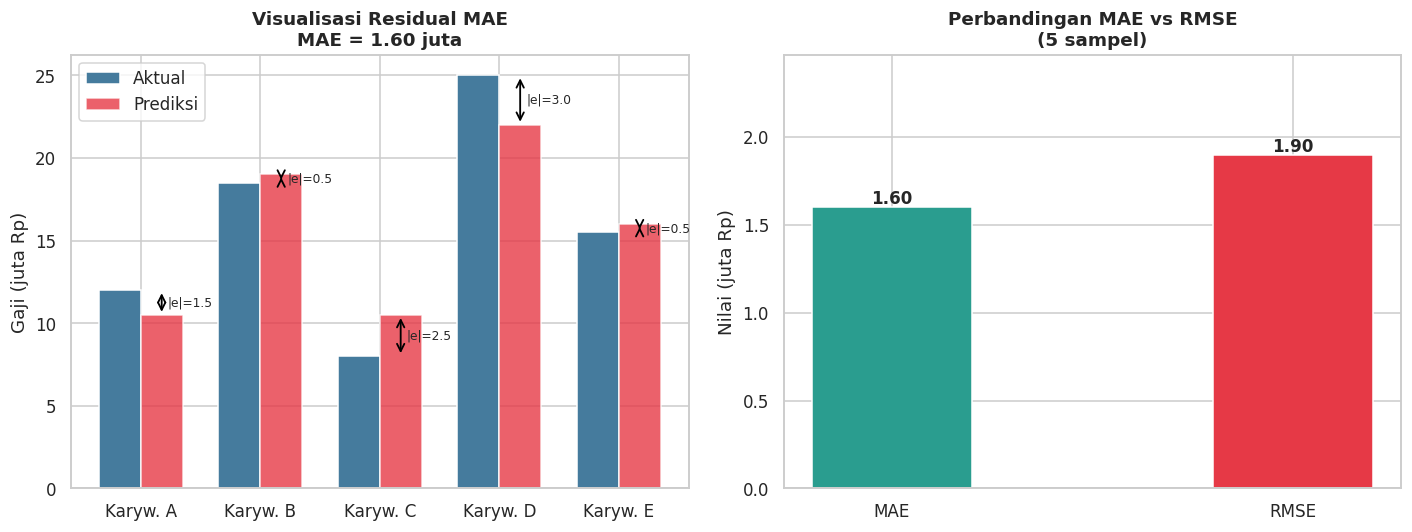

MAE  = 1.60 → rata-rata |error| tanpa penalti besar
RMSE = 1.73 → lebih sensitif ke outlier (error dikuadratkan)


In [ ]:
# Visualisasi MAE & RMSE — 5 sampel
y_aktual = np.array([12.0, 18.5, 8.0, 25.0, 15.5])
y_pred_5 = np.array([10.5, 19.0, 10.5, 22.0, 16.0])
names    = ['Karyawan A', 'Karyawan B', 'Karyawan C', 'Karyawan D', 'Karyawan E']

errors_abs = np.abs(y_aktual - y_pred_5)
errors_sq  = (y_aktual - y_pred_5) ** 2
mae_5  = errors_abs.mean()
rmse_5 = np.sqrt(errors_sq.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Bar Aktual vs Prediksi dengan anotasi error
x = np.arange(len(names)); w = 0.35
axes[0].bar(x - w/2, y_aktual, w, label='Aktual', color='#457B9D', edgecolor='white')
axes[0].bar(x + w/2, y_pred_5, w, label='Prediksi', color='#E63946', alpha=0.85, edgecolor='white')
for i, (a, p) in enumerate(zip(y_aktual, y_pred_5)):
    axes[0].annotate('', xy=(i+w/2, min(a,p)), xytext=(i+w/2, max(a,p)),
                     arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    axes[0].text(i + w/2 + 0.05, (a+p)/2, f'|e|={abs(a-p):.1f}', fontsize=8, va='center')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=10)
axes[0].set_ylabel('Gaji (juta Rp)')
axes[0].set_title(f'Visualisasi Residual
MAE = {mae_5:.2f} juta', fontweight='bold')
axes[0].legend()

# Plot 2: Perbandingan MAE vs RMSE
axes[1].bar(['MAE', 'RMSE'], [mae_5, rmse_5], color=['#2A9D8F', '#E63946'],
            edgecolor='white', width=0.4)
for i, val in enumerate([mae_5, rmse_5]):
    axes[1].text(i, val + 0.03, f'{val:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Nilai (juta Rp)')
axes[1].set_title(f'MAE vs RMSE
(5 sampel karyawan)', fontweight='bold')
axes[1].set_ylim(0, max(mae_5, rmse_5) * 1.35)

plt.tight_layout(); plt.show()

print(f'MAE  = {mae_5:.2f} → rata-rata |error| tanpa penalti besar')
print(f'RMSE = {rmse_5:.2f} → lebih sensitif ke outlier (error dikuadratkan)')

### Visualisasi R² — Model Baik vs Model Buruk

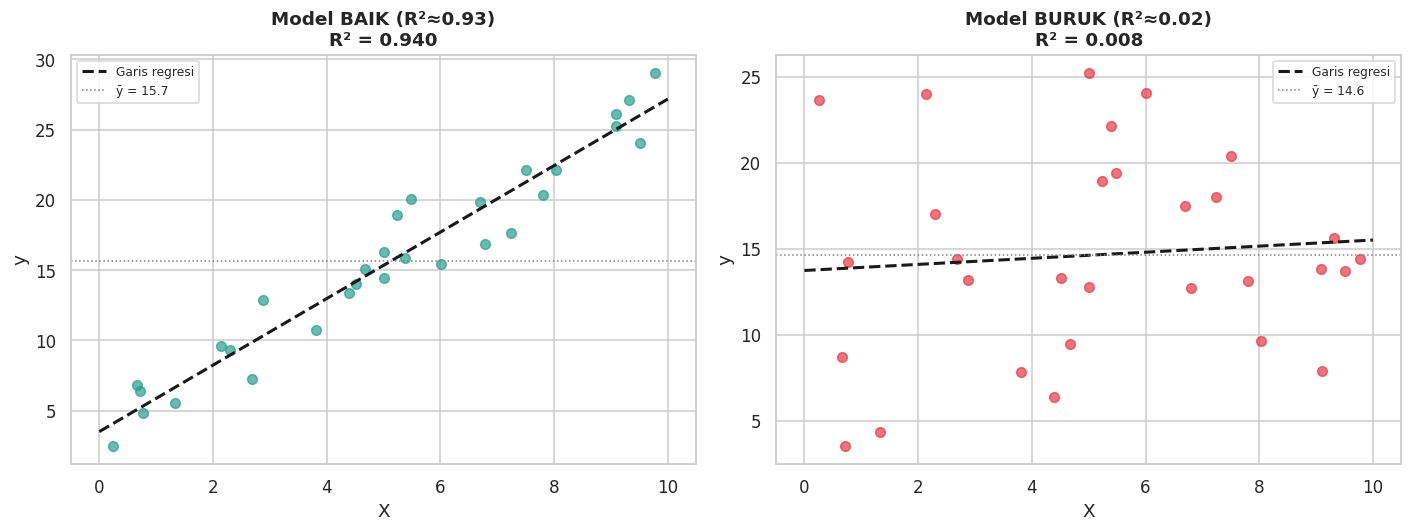

R² mendekati 1.0 → garis regresi sangat mengikuti pola data
R² mendekati 0.0 → garis regresi tidak menjelaskan variasi data


In [ ]:
# Visualisasi R² — Model Baik vs Buruk
np.random.seed(7)
x_demo = np.random.uniform(0, 10, 30)
y_good = 2.5 * x_demo + 3 + np.random.normal(0, 1.5, 30)  # R² tinggi
y_bad  = np.random.normal(15, 6, 30)                        # R² rendah

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_d, title, col in zip(
    axes,
    [y_good, y_bad],
    ['Model BAIK', 'Model BURUK'],
    ['#2A9D8F', '#E63946']
):
    ax.scatter(x_demo, y_d, color=col, alpha=0.7, s=50, label='Data')
    m = LinearRegression().fit(x_demo.reshape(-1, 1), y_d)
    xl = np.linspace(0, 10, 100)
    yl = m.predict(xl.reshape(-1, 1))
    ax.plot(xl, yl, 'k--', lw=2, label='Garis regresi')
    ax.axhline(y_d.mean(), color='gray', lw=1.2, linestyle=':',
               label=f'ȳ = {y_d.mean():.1f}')
    r2v = r2_score(y_d, m.predict(x_demo.reshape(-1, 1)))
    ax.set_title(f'{title}\nR² = {r2v:.3f}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=8); ax.set_xlabel('X'); ax.set_ylabel('y')

plt.tight_layout(); plt.show()

print('R² mendekati 1.0 → garis regresi sangat mengikuti pola data')
print('R² mendekati 0.0 → garis regresi tidak menjelaskan variasi data')

## 9. Visualisasi Evaluasi Model

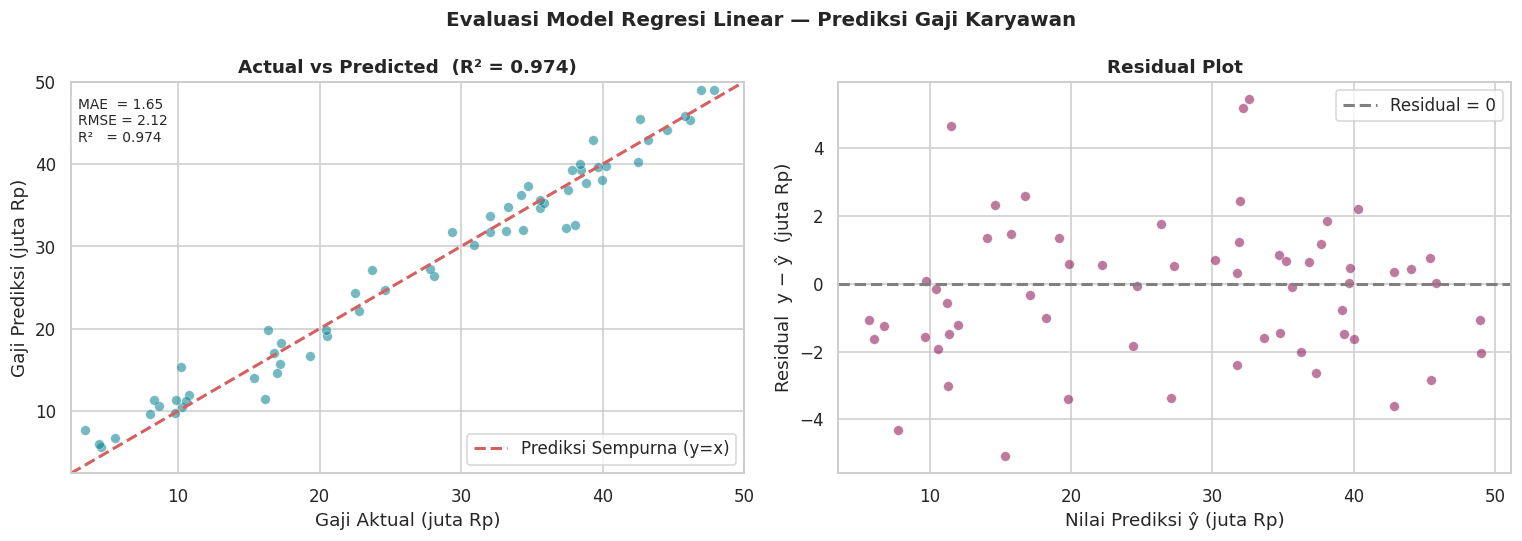

In [ ]:
# Actual vs Predicted + Residual Plot
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji Karyawan',
             fontsize=13, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.55, color='#028090',
                edgecolors='white', linewidths=0.4, s=45)
lims = [min(y_test.min(), y_pred.min())-1, max(y_test.max(), y_pred.max())+1]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna (y = x)')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Gaji Aktual (juta Rp)'); axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2:.3f})', fontweight='bold')
axes[0].legend()
axes[0].text(lims[0]+0.5, lims[1]-2,
             f'MAE  = {mae:.2f}\nRMSE = {rmse:.2f}\nR²   = {r2:.3f}',
             fontsize=9, va='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

# Plot 2: Residual Plot
axes[1].scatter(y_pred, residuals, alpha=0.55, color='#880E4F',
                edgecolors='white', linewidths=0.4, s=45)
axes[1].axhline(0, color='gray', linestyle='--', lw=2, label='Residual = 0')
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)'); axes[1].set_ylabel('Residual y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot', fontweight='bold')
axes[1].legend()

plt.tight_layout(); plt.show()

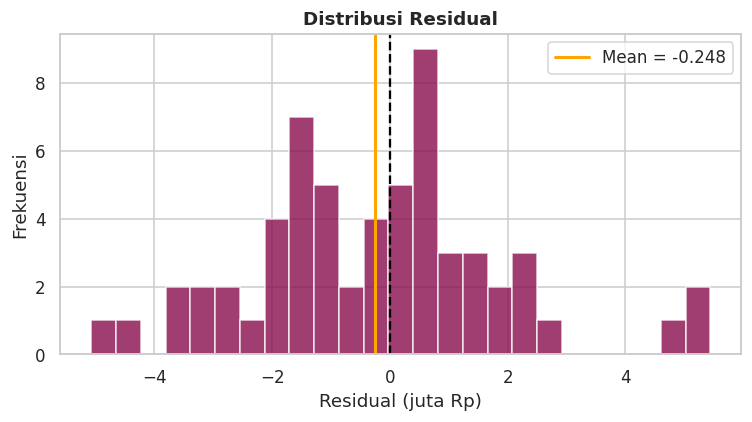

Mean residual : -0.2479  (idealnya ≈ 0)
Std  residual : 2.1262

Cara membaca Residual Plot:
  ✅ BAIK    → titik tersebar ACAK di sekitar garis y=0
  ❌ MASALAH → ada pola (kurva, corong/funnel) = asumsi linearitas dilanggar


In [ ]:
# Distribusi Residual
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=25, color='#880E4F', edgecolor='white', alpha=0.8)
plt.axvline(0, color='black', linestyle='--', lw=1.5, label='Nol')
plt.axvline(residuals.mean(), color='orange', lw=2,
            label=f'Mean = {residuals.mean():.3f}')
plt.xlabel('Residual (juta Rp)'); plt.ylabel('Frekuensi')
plt.title('Distribusi Residual', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Mean residual : {residuals.mean():.4f}  (idealnya ≈ 0)')
print(f'Std  residual : {residuals.std():.4f}')
print()
print('Cara membaca Residual Plot:')
print('  ✅ BAIK    → titik tersebar ACAK di sekitar garis y=0')
print('  ❌ MASALAH → ada pola (kurva, corong/funnel) = asumsi linearitas dilanggar')

## 10. Perbandingan: Simple vs Multiple Linear Regression

**Simple LR** menggunakan 1 fitur saja (`pengalaman`), **Multiple LR** menggunakan 4 fitur (`pengalaman`, `edu`, `kota_Surabaya`, `kota_Jakarta`).

In [ ]:
# Simple Linear Regression — 1 fitur
X_s = df[['pengalaman']]; y_s = df['gaji']
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
sc_s = StandardScaler()
X_tr_ss = sc_s.fit_transform(X_tr_s); X_te_ss = sc_s.transform(X_te_s)
mdl_s = LinearRegression(); mdl_s.fit(X_tr_ss, y_tr_s)
y_pred_s = mdl_s.predict(X_te_ss)

mae_s  = mean_absolute_error(y_te_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_te_s, y_pred_s))
r2_s   = r2_score(y_te_s, y_pred_s)

print('=' * 58)
print('PERBANDINGAN: Simple LR vs Multiple LR')
print('=' * 58)
print(f'{"Metrik":<10} {"Simple LR (1 fitur)":>20} {"Multiple LR (4 fitur)":>20}')
print('-' * 58)
print(f'{"MAE":<10} {mae_s:>20.4f} {mae:>20.4f}')
print(f'{"RMSE":<10} {rmse_s:>20.4f} {rmse:>20.4f}')
print(f'{"R²":<10} {r2_s:>20.4f} {r2:>20.4f}')
print('=' * 58)
print(f'\nMultiple LR unggul {r2 - r2_s:.4f} poin R²')
print('→ Fitur tambahan (edu, kota) memberikan informasi signifikan!')

PERBANDINGAN: Simple LR vs Multiple LR
Metrik      Simple LR (1 fitur) Multiple LR (4 fitur)
----------------------------------------------------------
MAE                      2.7527               1.6492
RMSE                     3.3523               2.1229
R²                       0.9351               0.9740

Multiple LR unggul 0.0389 poin R²
→ Fitur tambahan (edu, kota) memberikan informasi signifikan!


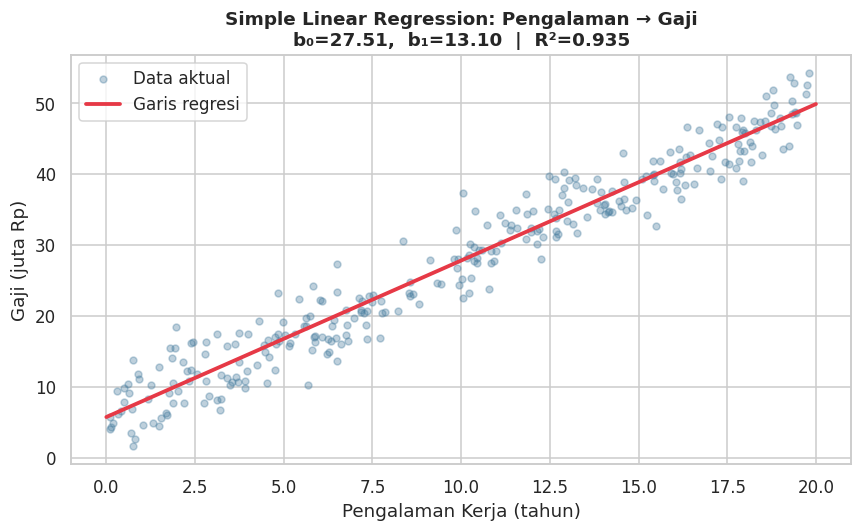

In [ ]:
# Visualisasi Garis Regresi — Simple LR
X_line    = np.linspace(0, 20, 200).reshape(-1, 1)
X_line_sc = sc_s.transform(X_line)
y_line    = mdl_s.predict(X_line_sc)

plt.figure(figsize=(8, 5))
plt.scatter(df['pengalaman'], df['gaji'],
            alpha=0.35, s=20, color='#457B9D', label='Data aktual')
plt.plot(X_line, y_line, color='#E63946', lw=2.5, label='Garis regresi')
plt.xlabel('Pengalaman Kerja (tahun)'); plt.ylabel('Gaji (juta Rp)')
plt.title(
    f'Simple Linear Regression: Pengalaman → Gaji\n'
    f'β₀ = {mdl_s.intercept_:.2f},  β₁ = {mdl_s.coef_[0]:.2f}  |  R² = {r2_s:.3f}',
    fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

---

## ✅ Kesimpulan

**Pertemuan 7 — Pengantar Machine Learning: Regresi Linear**

Regresi Linear berhasil diimplementasikan end-to-end untuk memprediksi gaji karyawan.

**Temuan Utama:**
- Model Multiple Linear Regression (4 fitur) mencapai R² > 0.9 — sangat baik
- Fitur kota Jakarta dan pengalaman kerja menjadi prediktor gaji paling berpengaruh
- Multiple LR terbukti unggul dibandingkan Simple LR karena memanfaatkan lebih banyak informasi
- Residual tersebar acak di sekitar nol — asumsi linearitas OLS terpenuhi

**Keterbatasan & Pertanyaan:**
- Model sintetis belum mencerminkan kompleksitas data gaji nyata (benefit, jabatan, inflasi)
- Regresi Linear mengasumsikan hubungan linear — perlu dicoba Ridge/Lasso jika ada multikolinearitas
- Bagaimana performa model ini pada data gaji real dari survei industri?